<a href="https://colab.research.google.com/github/luiz-zer0/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd
df=pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
print(len(df))
print(len(df.columns))

5268
13


In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
df.isna().any()

,0
Date,False
Time,True
Location,True
Operator,True
Flight #,True
Route,True
Type,True
Registration,True
cn/In,True
Aboard,True


In [ ]:
df.isnull()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,False,False,False,False,True,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,True,True,False,False,False,False
2,False,True,False,False,False,True,False,True,True,False,False,False,False
3,False,False,False,False,True,True,False,True,True,False,False,False,False
4,False,False,False,False,True,True,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,False,False,False,False,True,False,False,False,False,False,False,False,False
5264,False,True,False,False,True,False,False,False,False,False,False,True,False
5265,False,False,False,False,False,False,False,False,False,False,False,False,False
5266,False,False,False,False,True,False,False,False,False,False,False,False,False


-Time: Fill with "Unknown" - not critical to analyse but cannot be guessed.
-Location: Fill with "Unknown" or drop row - no way to interfer where crash happened.
-Operator: Fill with "Unknown" - no other column shows the operator being discussed.
-Route: Fill with "Unknown" - free text, can not be derived from other columns.
-Type: Fill with the mode (most common aircraft type) - some types repeat frequently making it reasonable to use as a guess.
-Registration: Fill with "Unknown" - Unique ID thus can not be interfered.
-cn/In: Fill with "Unknown" - Unique ID this can not be interfered.
-Aboard: Fill with median - it is numeric and skewed thus better to use than relying on mean.
-Fatalities: Fill with median - it is numeric and skewed thus better to use than relying on mean.
-Ground: Fill with 0 - missing value can mean no fatalities.
-Summary: Fill with "No summary available" - This will not affect any numerical analysis.

General rule: text/category columns get filled with "Unknown" (or the mode if a value ir repetitive); numeric columns get filled with the median rahter than the mean, since a few catastrophic crashes would distrort the average.

In [ ]:
fatality_locations=df[['Date','Location','Aboard','Fatalities',]].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
maximum_fatalities=df['Fatalities'].idxmax()
date_of_maximum_fatalities=df.loc[maximum_fatalities,'Date']
print("Highest fatalities were recorded on", date_of_maximum_fatalities)

Highest fatalities were recorded on 03/27/1977


In [ ]:
df[['Aboard', 'Fatalities']].head(20)
no_fatalities = df[df['Fatalities'] == 0]
print("Number of crashes with no fatalities:", len(no_fatalities))

Number of crashes with no fatalities: 58


In [ ]:
fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
fatality_locations = fatality_locations[['Region', 'State/Country']]
fatality_locations.head()

,Region,State/Country
2963,Tenerife,Canary Islands
3568,Mt. Osutaka,"near Ueno Village, Japan"
4455,Near Charkhidadri,India
2726,Near Ermenonville,France
3562,AtlantiOcean,110 miles West of Ireland


In [ ]:
fatality_locations = df.sort_values('Fatalities', ascending=False).head(100)
fatality_locations.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
2963,03/27/1977,17:07,"Tenerife, Canary Islands",Pan American World Airways / KLM,1736/4805,Tenerife - Las Palmas / Tenerife - Las Palmas,Boeing B-747-121 / Boeing B-747-206B,N736PA/PH-BUF,19643/11 / 20400/157,644.0,583.0,0.0,Both aircraft were diverted to Tenerife becaus...
3568,08/12/1985,18:56,"Mt. Osutaka, near Ueno Village, Japan",Japan Air Lines,123,Tokyo - Osaka,Boeing B-747-SR46,JA8119,20783/230,524.0,520.0,0.0,The aircraft suffered an aft pressure bulkhead...
4455,11/12/1996,18:40,"Near Charkhidadri, India",Saudi Arabian Airlines / Kazastan Airlines,763/1907,New Delhi - Dhahran / Chimkent - New Delhi,Boeing B-747-168B / Ilyushin IL-76TD,HZAIH/UN-76435,22748/555/1023413428,349.0,349.0,0.0,Midair collision 17 km W of New Delhi. The Sa...
2726,03/03/1974,11:41,"Near Ermenonville, France",Turkish Airlines (THY),981,Paris - London,McDonnell Douglas DC-10-10,TC-JAV,46704/29,346.0,346.0,0.0,The aircraft crashed shortly after takeoff fro...
3562,06/23/1985,07:15,"AtlantiOcean, 110 miles West of Ireland",Air India,182,Montreal - London,Boeing B-747-237B,VT-EFO,21473/330,329.0,329.0,0.0,The aircraft broke up in flight and crashed in...


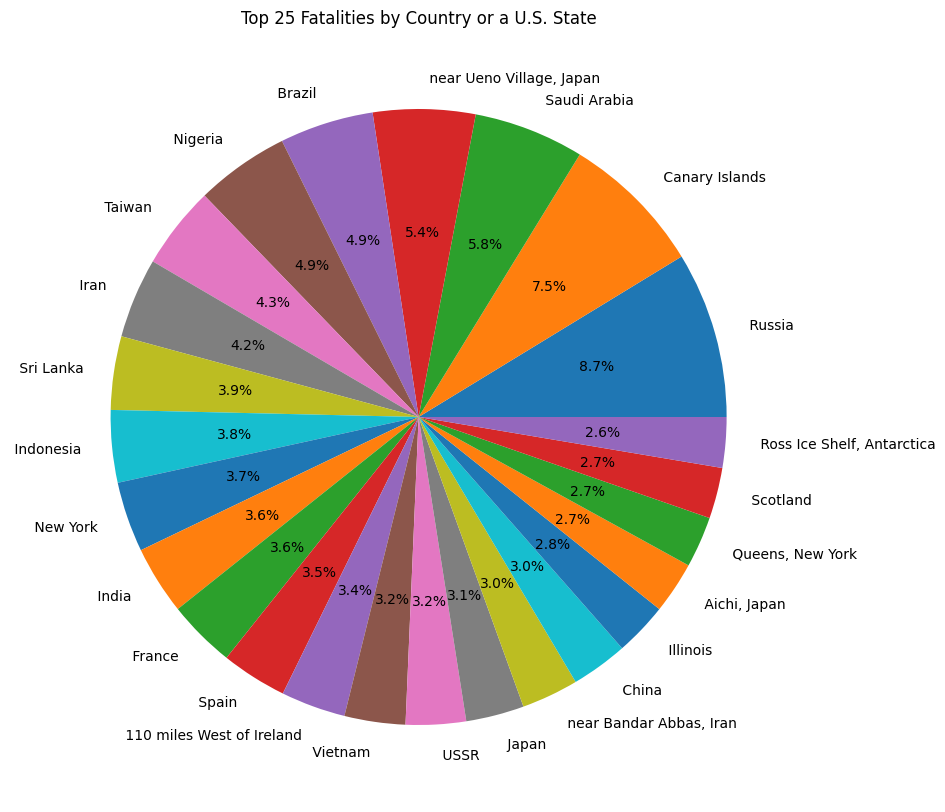

In [ ]:
import matplotlib.pyplot as plt

fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
top25 = fatality_locations.groupby('State/Country')['Fatalities'].sum().nlargest(25)
top25.plot.pie(figsize=(10, 10), autopct='%1.1f%%')
plt.ylabel('')
plt.title('Top 25 Fatalities by Country or a U.S. State')
plt.show()